In [79]:
import pandas as pd
import numpy as np
import seaborn as sn
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots


from datetime import datetime
import math



In [80]:
path = "/content/drive/MyDrive/Data Analysis Portfolio/"
File = "Market Campaign Analysis/marketing_campaign.csv"

In [81]:
#https://www.kaggle.com/datasets/rodsaldanha/arketing-campaign/data
data = pd.read_csv(path+File, sep=';' )
# from google.colab import sheets
# sheet = sheets.InteractiveSheet(df=data)

In [82]:
data.head(5)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


### Data Preprocessing:


In [83]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [84]:
data['Income'].isnull().sum()

np.int64(24)

In [85]:
##Income likely depends on Education or Marital_Status. You can impute by group median.

data['Income'] = data.groupby(['Education', 'Marital_Status'])['Income'] \
                  .transform(lambda x: x.fillna(x.median()))
data['Income'].isnull().sum()

np.int64(0)

###Feature Engineering


In [86]:
#Variable Age in replacement of the variable Year_birth
current_year = datetime.now().year
data['Age'] = current_year - data['Year_Birth']

#drop Year_Birth, we  don’t need it:
data.drop(columns=['Year_Birth'], inplace=True)

In [87]:
## Variable Spending as the sum of the amount spent on the 6 product categories

data['Spending'] = (
    data['MntWines'] +
    data['MntFruits'] +
    data['MntMeatProducts'] +
    data['MntFishProducts'] +
    data['MntSweetProducts'] +
    data['MntGoldProds']
)




In [88]:
##Marital_Situation — grouping into “In couple” vs “Alone”
print(data['Marital_Status'].unique())

data['Marital_Situation'] = data['Marital_Status'].replace({
    'Married': 'In_couple',
    'Together': 'In_couple',
    'Single': 'Alone',
    'Divorced': 'Alone',
    'Widow': 'Alone',
    'Alone': 'Alone',
    'YOLO': 'Alone',
    'Absurd': 'Alone'
})

#drop marital status, no lonhger needed
data.drop(columns=['Marital_Status'], inplace=True)

data['Marital_Situation'].unique()

['Single' 'Together' 'Married' 'Divorced' 'Widow' 'Alone' 'Absurd' 'YOLO']


array(['Alone', 'In_couple'], dtype=object)

In [89]:
#combine the variables  kidhome and teenhome into just one variable 'Has_child

data['No_children'] = ((data['Kidhome'] + data['Teenhome']) > 0).astype(int)

#or Y/N instead on int
#data['Has_child'] = ((data['Kidhome'] + data['Teenhome']) > 0).astype(int)

data.drop(columns='Kidhome' , inplace=True)
data.drop(columns='Teenhome' , inplace=True)

In [90]:
# #replace Graduations, 2nd Cycle with common names i.e Undergrad, HighSchool
# data['Education'] = data['Education'].replace({
#     'Graduation': 'Undergrad',
#     '2n Cycle': 'HighSchool'})
# data.head(5)

In [91]:
#replace Graduations, 2nd Cycle with common names i.e Undergrad, HighSchool
data['Education'] = data['Education'].replace({
    'Graduation': 'Undergrad',
    '2n Cycle': 'HighSchool'})

education_years_map = {
    'Basic': 9,
    'HighSchool': 12,
    'Undergrad': 16,
    'Master': 18,
    'PhD': 21
}

data['Educational_years'] = data['Education'].map(education_years_map)

data.drop(columns=['Education'], inplace=True)

In [92]:
#not useful for the analysis features
data.drop(columns=['ID', 'Z_CostContact', 'Z_Revenue'], inplace=True)

In [93]:
data.head()

,Income,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,Spending,Marital_Situation,No_children,Educational_years
0,58138.0,2012-09-04,58,635,88,546,172,88,88,3,...,0,0,0,0,1,69,1617,Alone,0,16
1,46344.0,2014-03-08,38,11,1,6,2,1,6,2,...,0,0,0,0,0,72,27,Alone,1,16
2,71613.0,2013-08-21,26,426,49,127,111,21,42,1,...,0,0,0,0,0,61,776,In_couple,0,16
3,26646.0,2014-02-10,26,11,4,20,10,3,5,2,...,0,0,0,0,0,42,53,In_couple,1,16
4,58293.0,2014-01-19,94,173,43,118,46,27,15,5,...,0,0,0,0,0,45,422,In_couple,1,21


### Statitical Summary

In [94]:
data.describe()

,Income,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,...,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,Spending,No_children,Educational_years
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,52231.860714,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,...,0.074554,0.072768,0.064286,0.013393,0.009375,0.149107,57.194196,605.798214,0.715179,16.883929
std,25039.866195,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,...,0.262728,0.259813,0.245316,0.114976,0.096391,0.356274,11.984069,602.249288,0.451430,2.817496
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,30.000000,5.000000,0.000000,9.000000
25%,35538.750000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,49.000000,68.750000,0.000000,16.000000
50%,51222.500000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,56.000000,396.000000,1.000000,16.000000
75%,68289.750000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67.000000,1045.500000,1.000000,18.000000
max,666666.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,133.000000,2525.000000,1.000000,21.000000


---

#Customer Profile

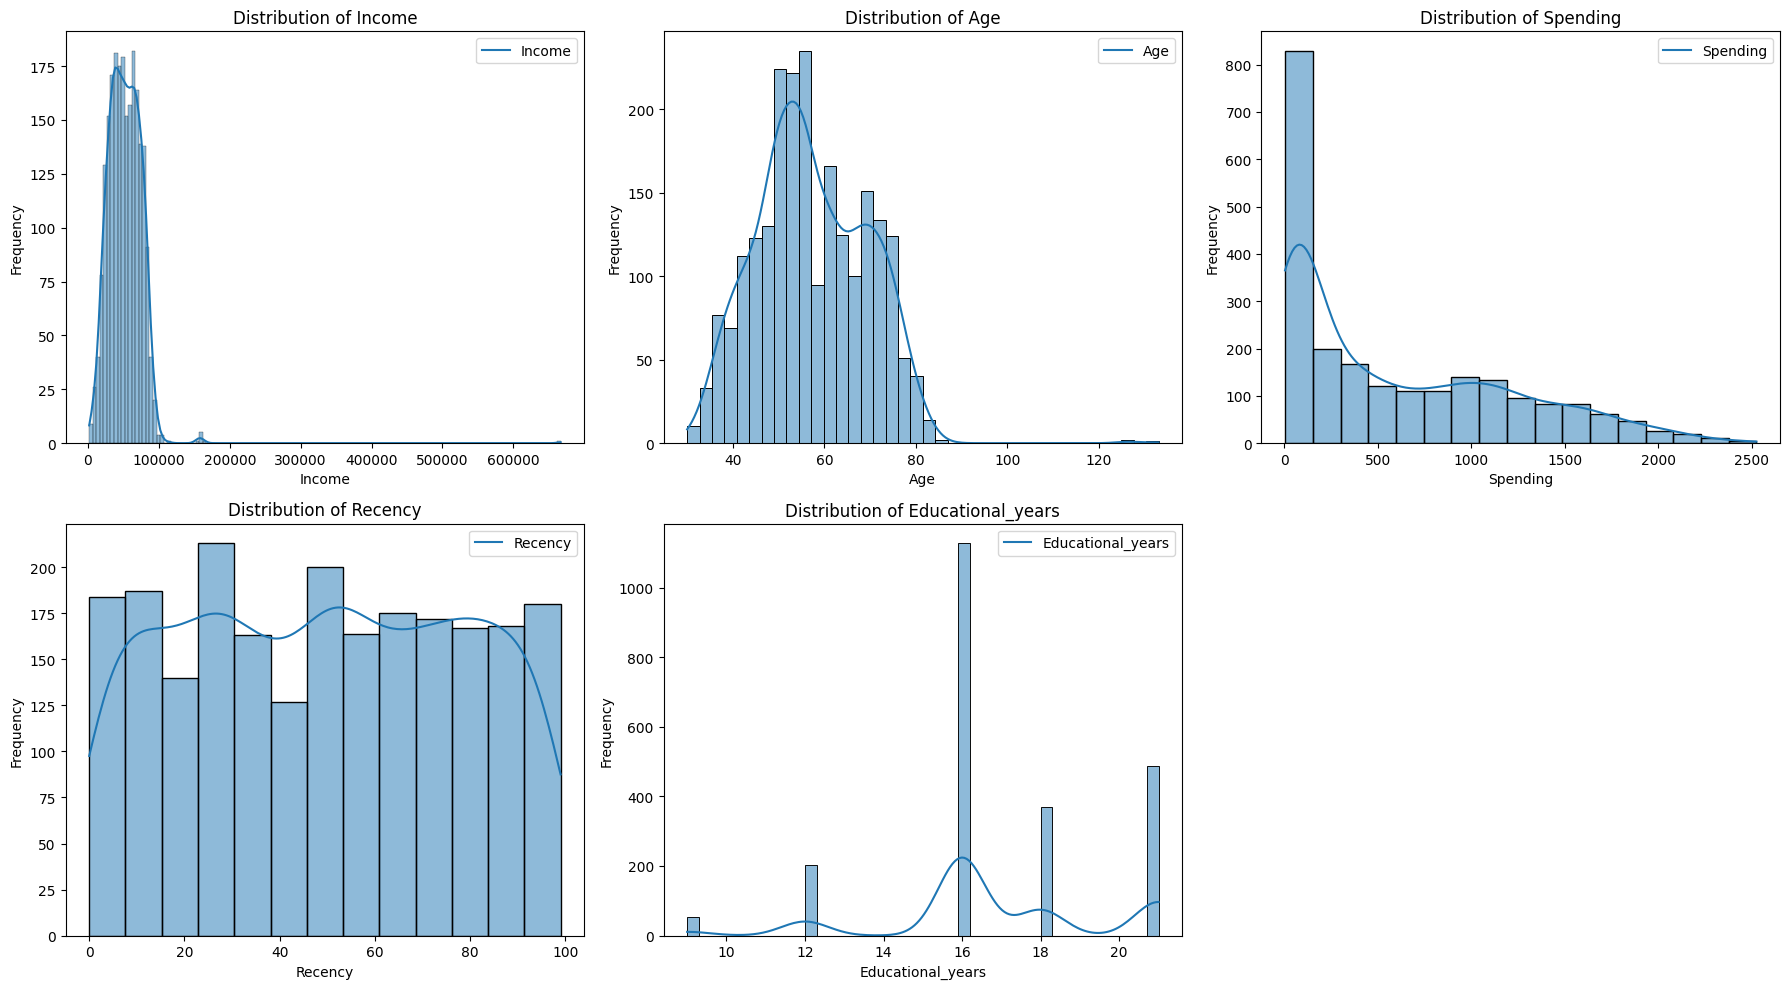

In [95]:
numerical_features = ['Income', 'Age', 'Spending', 'Recency', 'Educational_years']

# Define number of columns
cols = 3
rows = math.ceil(len(numerical_features) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
axes = axes.flatten()  # Flatten in case of multiple rows

for i, feature in enumerate(numerical_features):
    sn.histplot(data=data, x=feature, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency')
    axes[i].legend([feature])

# Remove empty subplots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


### Customer Persona

* Middle-aged (45–65)
* Moderately to highly educated
* Mostly middle-income with a few wealthy outliers
* Generally low-to-moderate spenders, with a small VIP segment
* Mixed engagement levels (not strongly recent or inactive)


### Marketing Insights

* Segment Customers:

  * High spenders $→$ premium campaigns
  * Low spenders $→$ volume-based promotions
* Leverage education level:

  * Likely responsive to informational or value-driven messaging
* Recency neutrality

  * Campaign timing and personalization can significantly shift engagement



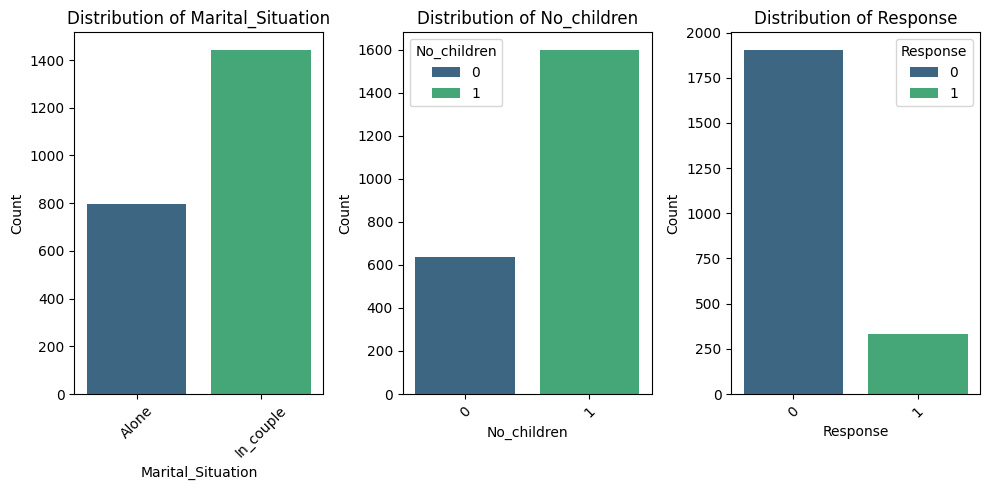

In [96]:
categorical_features = ['Marital_Situation', 'No_children', 'Response']

# Define number of columns
cols = 3
rows = math.ceil(len(categorical_features) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(10, 5 * rows))
axes = axes.flatten()

for i, feature in enumerate(categorical_features):
    sn.countplot(data=data, x=feature, hue=feature, palette='viridis', ax=axes[i])
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)  # rotate labels if crowded

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [97]:
##extract all numerical columns from the DataFrame to prepare for the correlation heatmap visualizatio

numerical_df = data.select_dtypes(include=np.number)
numerical_df.head()

,Income,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,...,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,Spending,No_children,Educational_years
0,58138.0,58,635,88,546,172,88,88,3,8,...,0,0,0,0,0,1,69,1617,0,16
1,46344.0,38,11,1,6,2,1,6,2,1,...,0,0,0,0,0,0,72,27,1,16
2,71613.0,26,426,49,127,111,21,42,1,8,...,0,0,0,0,0,0,61,776,0,16
3,26646.0,26,11,4,20,10,3,5,2,2,...,0,0,0,0,0,0,42,53,1,16
4,58293.0,94,173,43,118,46,27,15,5,5,...,0,0,0,0,0,0,45,422,1,21


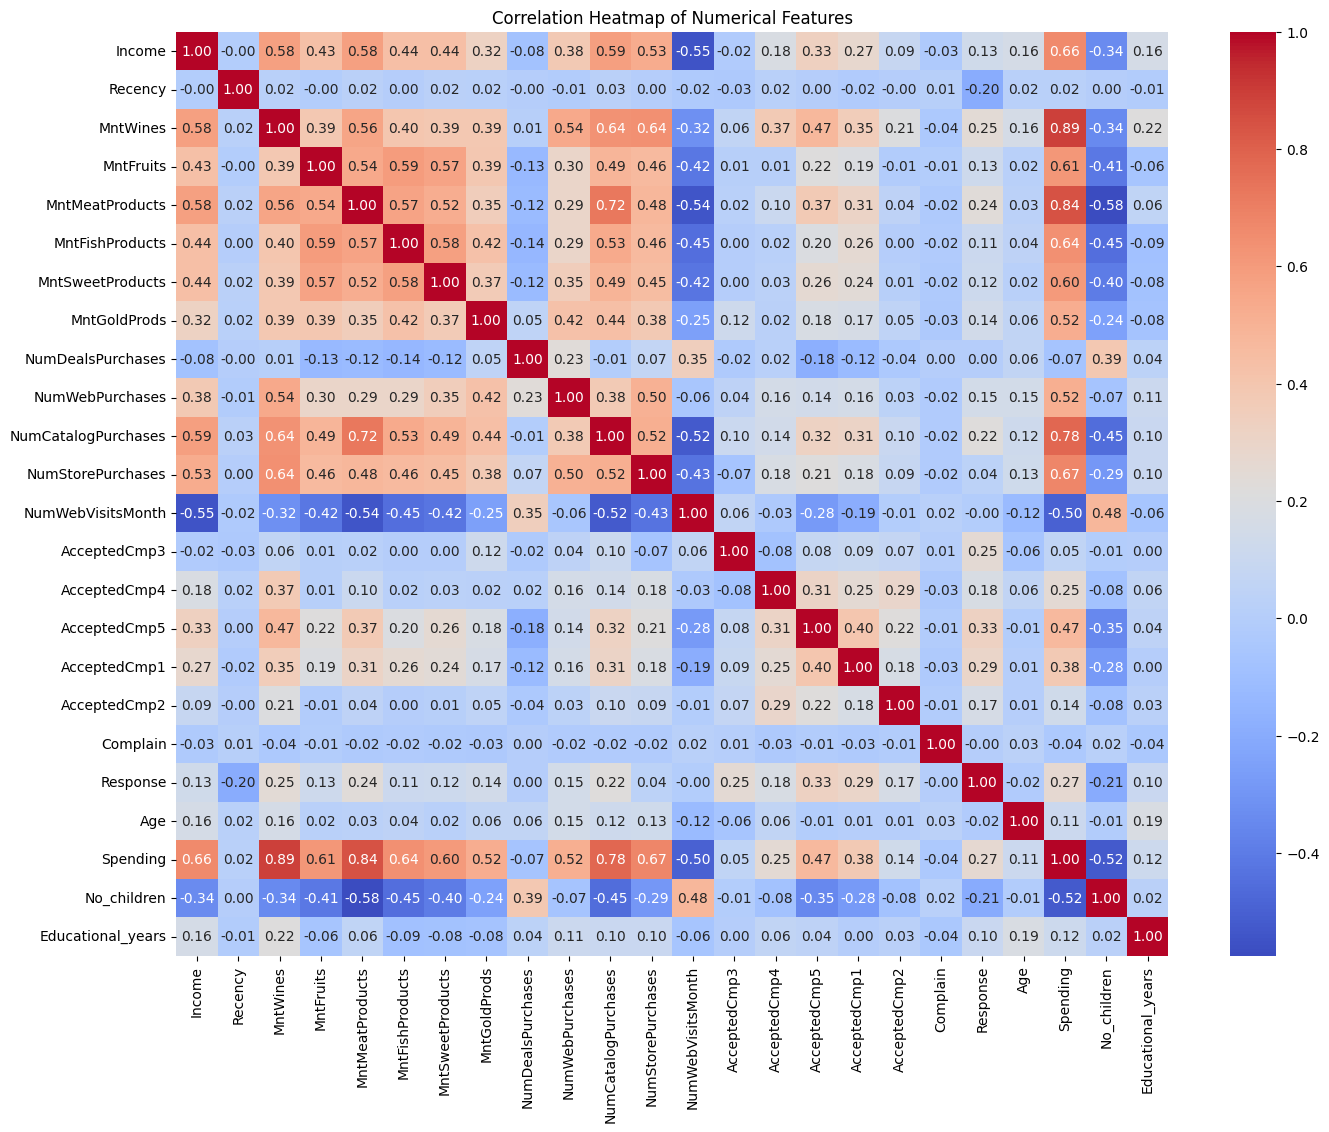

In [98]:
plt.figure(figsize=(16, 12))
sn.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

**Insights**

      Higher-income customers:

        - Spend significantly more

        - Buy more premium products (wine, meat)

        - Purchase more via catalog and store

# Relationships between campaign acceptance  vs Income, Age, Spending and Marital Situation

In [99]:
campaign_columns = ['AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2']
numerical_features = ['Income', 'Age', 'Spending']
categorical_feature = 'Marital_Situation'

In [100]:
# n_rows = len(campaign_columns)
# n_cols = len(numerical_features)

# fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows), squeeze=False)

# for i, campaign_col in enumerate(campaign_columns):
#     for j, num_feature in enumerate(numerical_features):
#         ax = axes[i, j]

#         sn.boxplot(
#             data=data,
#             x=campaign_col,
#             y=num_feature,
#             hue=campaign_col,
#             palette='viridis',
#             legend=False,
#             ax=ax
#         )

#         ax.set_title(f'{num_feature} by {campaign_col}')
#         ax.set_xlabel('Campaign Acceptance')
#         ax.set_ylabel(num_feature)
#         ax.grid(axis='y', linestyle='--', alpha=0.7)

# plt.tight_layout()
# plt.show()

In [101]:
n_cols = 4
n_rows = (len(campaign_columns) + n_cols - 1) // n_cols

fig = make_subplots(
    rows=n_rows,
    cols=n_cols,
    subplot_titles=campaign_columns
)

#Define consistent colors
color_map = {0: "#636EFA", 1: "#EF553B"}  # blue / red

# Track if legend already shown
legend_shown = {0: False, 1: False}

for i, campaign_col in enumerate(campaign_columns):
    row = i // n_cols + 1
    col = i % n_cols + 1

    grouped = data.groupby([categorical_feature, campaign_col]).size().reset_index(name='count')

    for val in sorted(grouped[campaign_col].unique()):
        df_plot = grouped[grouped[campaign_col] == val]

        fig.add_trace(
            go.Bar(
                x=df_plot[categorical_feature],
                y=df_plot['count'],
                name=str(val),                    #clean legend label
                legendgroup=str(val),             #group across plots
                showlegend=not legend_shown[val], #show only once
                marker_color=color_map[val],      #consistent color
                text=df_plot['count'],
                textposition='outside'
            ),
            row=row,
            col=col
        )

        legend_shown[val] = True  # mark as shown

fig.update_layout(
    height=400 * n_rows,
    width=300 * n_cols,
    title_text="Campaign Acceptance by Marital Situation",
    legend_title_text="Accepted Campaign"
)

fig.show()

### Insights

**Campaign Acceptance vs. Numerical Features (Income, Age, Spending):**

*   **Income:** Customers with higher incomes tend to accept campaigns more frequently, especially for campaigns like AcceptedCmp5 and AcceptedCmp1. The box plots show a noticeable shift towards higher median income for those who accepted these campaigns.
*   **Spending:** There is a strong positive correlation between higher spending and campaign acceptance across most campaigns. This aligns with the income insight, as higher income often leads to higher spending. AcceptedCmp5 and AcceptedCmp1 again show a significant difference in spending between acceptors and non-acceptors.
*   **Age:** The relationship between age and campaign acceptance appears less consistent or pronounced than with income and spending. For some campaigns, there might be a slight tendency for a particular age group to accept more (e.g., slightly older customers for some campaigns), but it's not a uniform trend across all campaigns.

**Campaign Acceptance vs. Marital_Situation:**

*   **Marital Situation:** The count plots reveal differences in campaign acceptance based on marital status. For instance, 'In_couple' customers might show a different acceptance rate compared to 'Alone' customers for specific campaigns. For example, some campaigns might be more appealing to couples, while others might resonate more with individuals living alone. The absolute numbers of customers 'In_couple' are generally higher, so it's important to consider the *proportion* of acceptance within each group rather than just raw counts.

# Response distribution

In [108]:
# subplots layout
fig = make_subplots(
    rows=2, cols=3,
    subplot_titles=[
        "Response Distribution",
        "Spending by Response",
        "Recency by Response",
        "Children vs Response",
        "Income vs Response",
        ""
    ]
)

# Response Distribution
resp_counts = data['Response'].value_counts().reset_index()
resp_counts.columns = ['Response', 'Count']

fig.add_trace(
    go.Bar(x=resp_counts['Response'], y=resp_counts['Count']),
    row=1, col=1
)

# Spending vs Response (Boxplot)
fig.add_trace(
    go.Box(x=data['Response'], y=data['Spending'], name="Spending"),
    row=1, col=2
)

# Recency vs Response (Boxplot)
fig.add_trace(
    go.Box(x=data['Response'], y=data['Recency'], name="Recency"),
    row=1, col=3
)

# Children vs Response
children_resp = data.groupby(['No_children', 'Response']).size().reset_index(name='Count')

for resp in children_resp['Response'].unique():
    subset = children_resp[children_resp['Response'] == resp]
    fig.add_trace(
        go.Bar(
            x=subset['No_children'],
            y=subset['Count'],
            name=f"Response {resp}"
        ),
        row=2, col=1
    )

# Income vs Response (Boxplot)
fig.add_trace(
    go.Box(x=data['Response'], y=data['Income'], name="Income"),
    row=2, col=2
)

# Layout improvements
fig.update_layout(
    height=700,
    width=1100,
    title_text="Customer Campaign Response",
    showlegend=True
)

fig.update_layout(
    template="plotly_white"
)

fig.show()

Customers who are recently active and spend more money are significantly more likely to respond to campaigns, while demographic factors like children and income play a smaller role.

### Overall Suggestions:


1.   Focus campaigns on high spenders and recently active customers
2.   Improve Low Response Rate
  * Current campaigns are too broad
  * Use segmentation instead of mass targeting

